In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import pairwise_distances
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('ship.csv')
df.head()


,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581


In [22]:
df.shape

(2736, 18)

In [23]:
print(df.isnull().sum())

Date                         0
Ship_Type                  136
Route_Type                 136
Engine_Type                136
Maintenance_Status         136
Speed_Over_Ground_knots      0
Engine_Power_kW              0
Distance_Traveled_nm         0
Draft_meters                 0
Weather_Condition          136
Cargo_Weight_tons            0
Operational_Cost_USD         0
Revenue_per_Voyage_USD       0
Turnaround_Time_hours        0
Efficiency_nm_per_kWh        0
Seasonal_Impact_Score        0
Weekly_Voyage_Count          0
Average_Load_Percentage      0
dtype: int64


In [24]:
df['Route_Type'].fillna(df['Route_Type'].mode()[0], inplace=True)
df['Ship_Type'].fillna(df['Ship_Type'].mode()[0], inplace=True)
df['Engine_Type'].fillna(df['Engine_Type'].mode()[0], inplace=True)
df['Maintenance_Status'].fillna(df['Maintenance_Status'].mode()[0], inplace=True)
df['Weather_Condition'].fillna(df['Ship_Type'].mode()[0], inplace=True)

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_5592\633438026.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Route_Type'].fillna(df['Route_Type'].mode()[0], inplace=True)
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_5592\633438026.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [25]:
print(df.isnull().sum())

Date                       0
Ship_Type                  0
Route_Type                 0
Engine_Type                0
Maintenance_Status         0
Speed_Over_Ground_knots    0
Engine_Power_kW            0
Distance_Traveled_nm       0
Draft_meters               0
Weather_Condition          0
Cargo_Weight_tons          0
Operational_Cost_USD       0
Revenue_per_Voyage_USD     0
Turnaround_Time_hours      0
Efficiency_nm_per_kWh      0
Seasonal_Impact_Score      0
Weekly_Voyage_Count        0
Average_Load_Percentage    0
dtype: int64


In [26]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

numerical_cols = [
    'Speed_Over_Ground_knots', 'Engine_Power_kW', 'Distance_Traveled_nm',
    'Draft_meters', 'Cargo_Weight_tons', 'Operational_Cost_USD',
    'Revenue_per_Voyage_USD', 'Turnaround_Time_hours', 'Efficiency_nm_per_kWh',
    'Seasonal_Impact_Score', 'Weekly_Voyage_Count', 'Average_Load_Percentage'
]
df_no_outliers = remove_outliers_iqr(df, numerical_cols)
print(f"Было: {len(df)}, стало: {len(df_no_outliers)}")
df = df_no_outliers.reset_index(drop=True)

Было: 2736, стало: 2736


In [27]:
categorical_cols = ['Ship_Type', 'Route_Type', 'Engine_Type', 'Maintenance_Status', 'Weather_Condition']
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

In [28]:
df_cluster = df.drop(columns=['Date'])
X = df_cluster.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

## Задание 1. Кластеризация

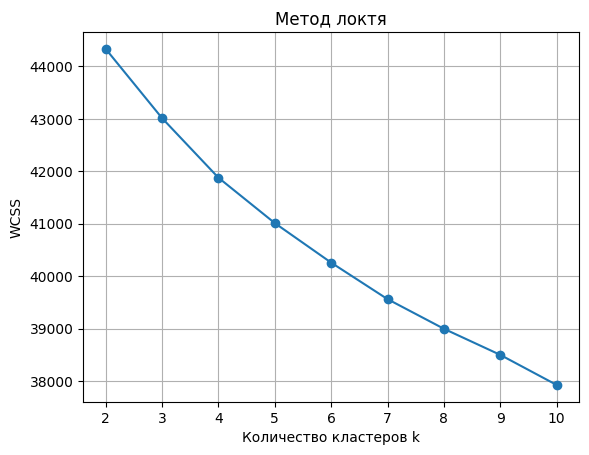

In [34]:
wcss = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(K_range, wcss, marker='o')
plt.title('Метод локтя')
plt.xlabel('Количество кластеров k')
plt.ylabel('WCSS')
plt.grid()
plt.show()

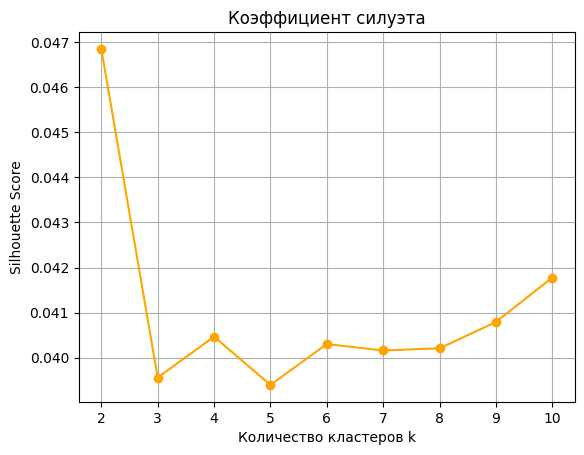

Лучшее k по силуэту: 2


In [30]:
sil_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_avg = silhouette_score(X_scaled, labels)
    sil_scores.append(sil_avg)
plt.plot(K_range, sil_scores, marker='o', color='orange')
plt.title('Коэффициент силуэта')
plt.xlabel('Количество кластеров k')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()
best_k = K_range[np.argmax(sil_scores)]
print(f"Лучшее k по силуэту: {best_k}")

In [35]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
start_time = time.time()
labels_kmeans = kmeans.fit_predict(X_scaled)
time_kmeans = time.time() - start_time
sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)
ch_kmeans = calinski_harabasz_score(X_scaled, labels_kmeans)
print(f"KMeans метрики (k={best_k}):")
print(f"Silhouette: {sil_kmeans:.3f}")
print(f"Davies-Bouldin: {db_kmeans:.3f}")
print(f"Calinski-Harabasz: {ch_kmeans:.1f}")
print(f"Время обучения: {time_kmeans:.2f} сек")

KMeans метрики (k=2):
Silhouette: 0.047
Davies-Bouldin: 4.472
Calinski-Harabasz: 134.4
Время обучения: 0.11 сек


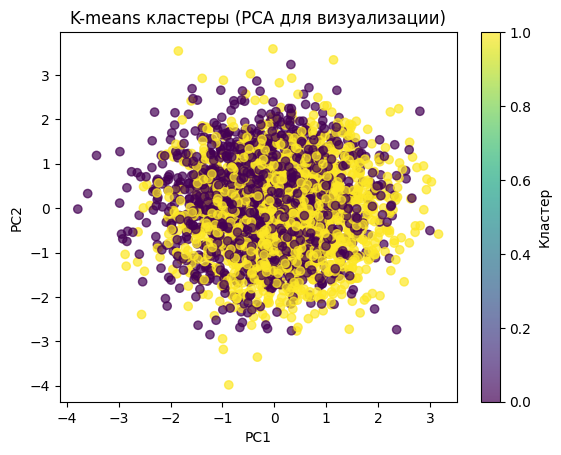

In [ ]:
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_scaled)
plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.7)
plt.title('K-means кластеры (PCA для визуализации)')
plt.colorbar(label='Кластер')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

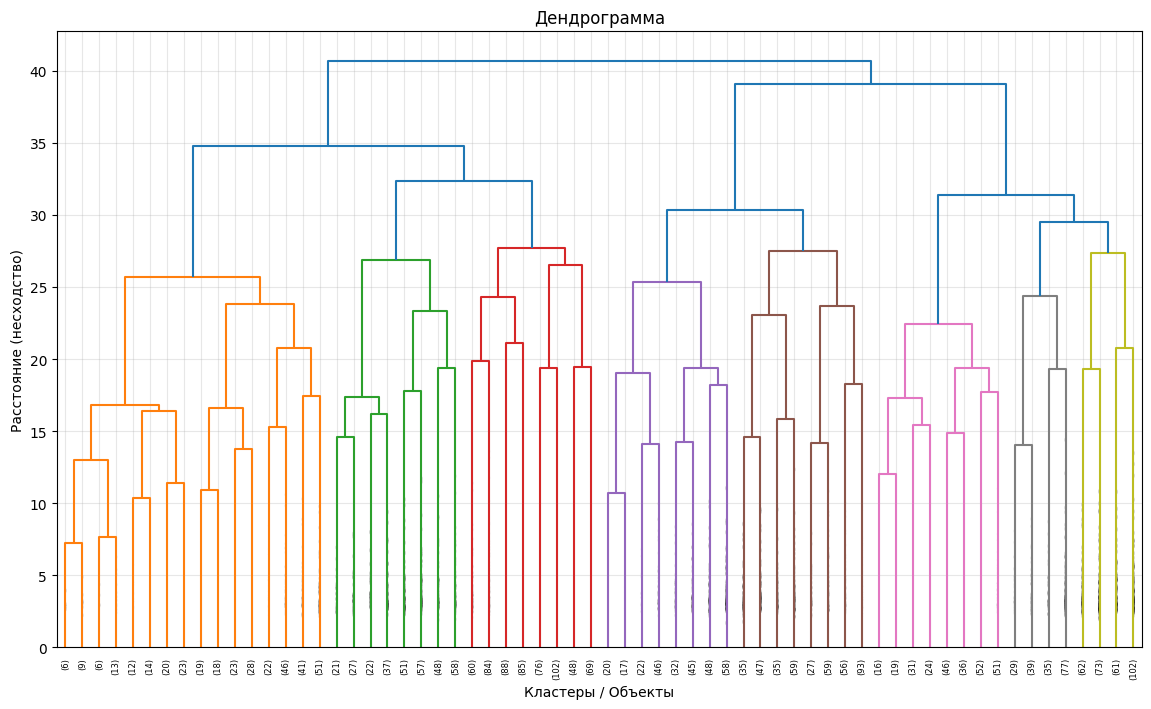

In [38]:
linkage_full = linkage(X_scaled, method='ward')
plt.figure(figsize=(14, 8))
dendrogram(linkage_full, truncate_mode='level', p=5, show_contracted=True)
plt.title('Дендрограмма')
plt.xlabel('Кластеры / Объекты')
plt.ylabel('Расстояние (несходство)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

def evaluate_hierarchical(X, k_range, linkage='ward'):
    sil_scores = []
    db_scores = []
    ch_scores = []
    times = []
    for k in k_range:
        start = time.time()
        agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = agg.fit_predict(X)
        end = time.time()
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        sil_scores.append(sil)
        db_scores.append(db)
        ch_scores.append(ch)
        times.append(end - start)
    return sil_scores, db_scores, ch_scores, times

In [ ]:
k_range = range(2, 11)
sil_ward, db_ward, ch_ward, time_ward = evaluate_hierarchical(X_scaled, k_range, linkage='ward')
sil_avg, db_avg, ch_avg, time_avg = evaluate_hierarchical(X_scaled, k_range, linkage='average')

In [41]:
best_k_ward = k_range[np.argmax(sil_ward)]
best_sil_ward = max(sil_ward)
best_k_avg = k_range[np.argmax(sil_avg)]
best_sil_avg = max(sil_avg)
print(f"Ward:   лучшее k = {best_k_ward}, Silhouette = {best_sil_ward:.3f}")
print(f"Average: лучшее k = {best_k_avg}, Silhouette = {best_sil_avg:.3f}")

Ward:   лучшее k = 2, Silhouette = 0.018
Average: лучшее k = 2, Silhouette = 0.095


In [45]:
best_linkage = 'average'
best_k_hier = best_k_ward
agg_final = AgglomerativeClustering(n_clusters=best_k_hier, linkage=best_linkage)
start = time.time()
labels_hier = agg_final.fit_predict(X_scaled)
time_hier = time.time() - start
sil_hier = silhouette_score(X_scaled, labels_hier)
db_hier = davies_bouldin_score(X_scaled, labels_hier)
ch_hier = calinski_harabasz_score(X_scaled, labels_hier)
print(f"Итог иерархической кластеризации ({best_linkage}, k={best_k_hier}):")
print(f"Silhouette: {sil_hier:.3f}")
print(f"Davies-Bouldin: {db_hier:.3f}")
print(f"Calinski-Harabasz: {ch_hier:.1f}")
print(f"Время: {time_hier:.2f} сек")

Итог иерархической кластеризации (average, k=2):
Silhouette: 0.095
Davies-Bouldin: 1.640
Calinski-Harabasz: 3.1
Время: 0.20 сек


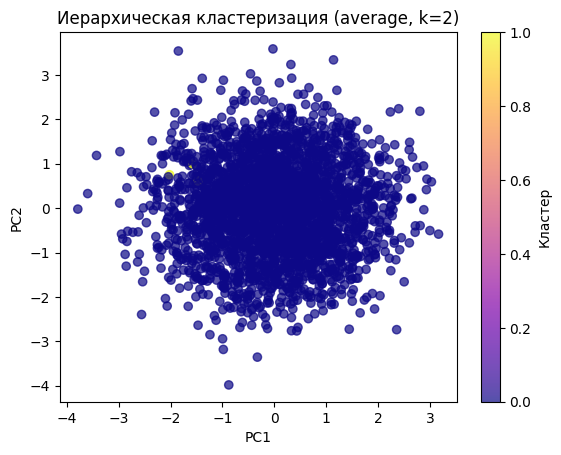

In [44]:
plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=labels_hier, cmap='plasma', alpha=0.7)
plt.title(f'Иерархическая кластеризация ({best_linkage}, k={best_k_hier})')
plt.colorbar(label='Кластер')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

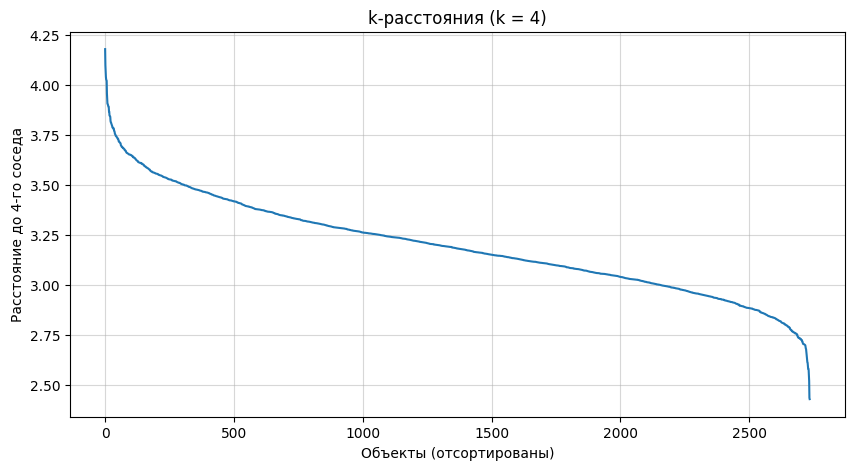

In [ ]:
from sklearn.neighbors import NearestNeighbors
min_samples = 5
k = min_samples - 1
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
distances_to_kth = np.sort(distances[:, -1], axis=0)[::-1]
plt.figure(figsize=(10, 5))
plt.plot(distances_to_kth)
plt.title('k-расстояния (k = 4)')
plt.xlabel('Объекты (отсортированы)')
plt.ylabel(f'Расстояние до {k}-го соседа')
plt.grid(True, alpha=0.5)
plt.show()

In [56]:
def test_dbscan(X, eps, min_samples):
    start = time.time()
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)
    time_taken = time.time() - start
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    if n_clusters >= 2:
        sil = silhouette_score(X, labels)
        db_idx = davies_bouldin_score(X, labels)
        ch_idx = calinski_harabasz_score(X, labels)
    else:
        sil = db_idx = ch_idx = np.nan
    return {
        'eps': eps,
        'min_samples': min_samples,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette': sil,
        'davies_bouldin': db_idx,
        'calinski_harabasz': ch_idx,
        'time': time_taken,
        'labels': labels
    }
test_params = [
    (3.5, 5),
    (2.75, 10),
    (3.0, 5),
    (3.2, 5)
]

results = []
for eps, ms in test_params:
    res = test_dbscan(X_scaled, eps, ms)
    results.append(res)
    print(f"eps={eps}, min_samples={ms} -> кластеров: {res['n_clusters']}, шум: {res['n_noise']}, время: {res['time']:.2f} сек")

eps=3.5, min_samples=5 -> кластеров: 1, шум: 65, время: 0.03 сек
eps=2.75, min_samples=10 -> кластеров: 0, шум: 2736, время: 0.01 сек
eps=3.0, min_samples=5 -> кластеров: 37, шум: 1748, время: 0.01 сек
eps=3.2, min_samples=5 -> кластеров: 3, шум: 620, время: 0.02 сек


In [57]:
valid_results = [r for r in results if r['n_clusters'] >= 2 and not np.isnan(r['silhouette'])]
best = max(valid_results, key=lambda r: r['silhouette'])
print("Лучший результат DBSCAN:")
for k, v in best.items():
    if k != 'labels':
        print(f"{k}: {v}")

Лучший результат DBSCAN:
eps: 3.2
min_samples: 5
n_clusters: 3
n_noise: 620
silhouette: -0.046170459525749497
davies_bouldin: 12.552899578823787
calinski_harabasz: 3.1527507822844005
time: 0.016017436981201172


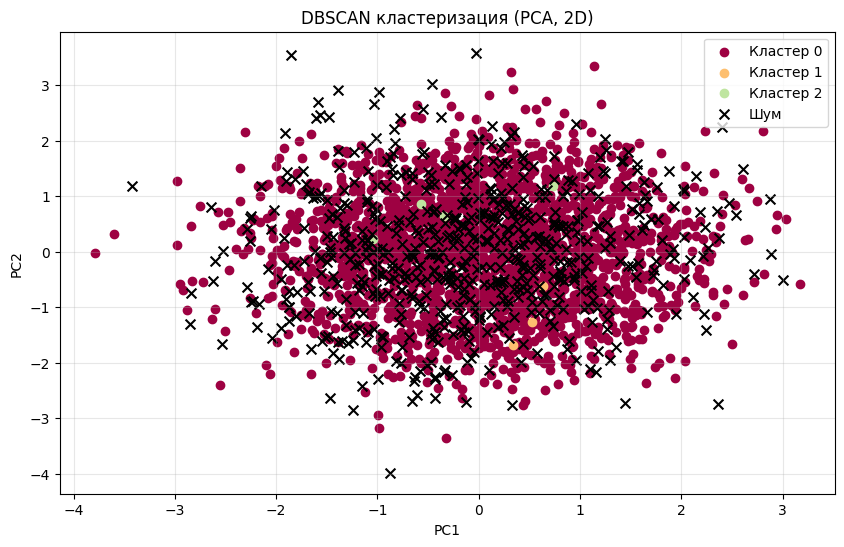

In [58]:
if 'best' in locals() and 'labels' in best:
    labels_dbscan = best['labels']
    plt.figure(figsize=(10, 6))
    unique_labels = set(labels_dbscan)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
    for label, color in zip(unique_labels, colors):
        if label == -1:
            plt.scatter(X_pca_viz[labels_dbscan == label, 0],
                        X_pca_viz[labels_dbscan == label, 1],
                        c='black', marker='x', s=50, label='Шум')
        else:
            plt.scatter(X_pca_viz[labels_dbscan == label, 0],
                        X_pca_viz[labels_dbscan == label, 1],
                        c=[color], label=f'Кластер {label}')
    plt.title('DBSCAN кластеризация (PCA, 2D)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [59]:
from sklearn.decomposition import PCA
pca_2d = PCA(n_components=2)
pca_3d = PCA(n_components=3)
X_pca_2d = pca_2d.fit_transform(X_scaled)
X_pca_3d = pca_3d.fit_transform(X_scaled)

In [60]:
print("Объяснённая дисперсия (2D):", pca_2d.explained_variance_ratio_)
print("Суммарно (2D):", np.sum(pca_2d.explained_variance_ratio_))
print("\nОбъяснённая дисперсия (3D):", pca_3d.explained_variance_ratio_)
print("Суммарно (3D):", np.sum(pca_3d.explained_variance_ratio_))

Объяснённая дисперсия (2D): [0.06612016 0.06510954]
Суммарно (2D): 0.13122970237686396

Объяснённая дисперсия (3D): [0.06612016 0.06510954 0.06373867]
Суммарно (3D): 0.19496837194057706


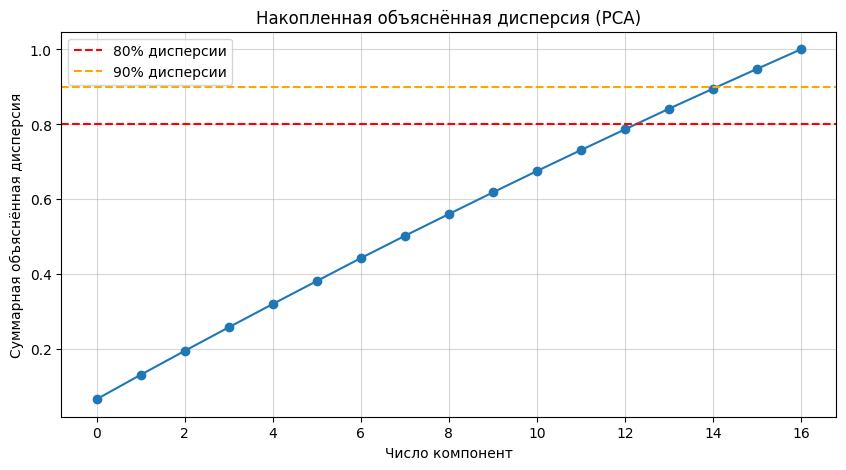

In [61]:
pca_full = PCA()
pca_full.fit(X_scaled)
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.axhline(y=0.8, color='red', linestyle='--', label='80% дисперсии')
plt.axhline(y=0.9, color='orange', linestyle='--', label='90% дисперсии')
plt.title('Накопленная объяснённая дисперсия (PCA)')
plt.xlabel('Число компонент')
plt.ylabel('Суммарная объяснённая дисперсия')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

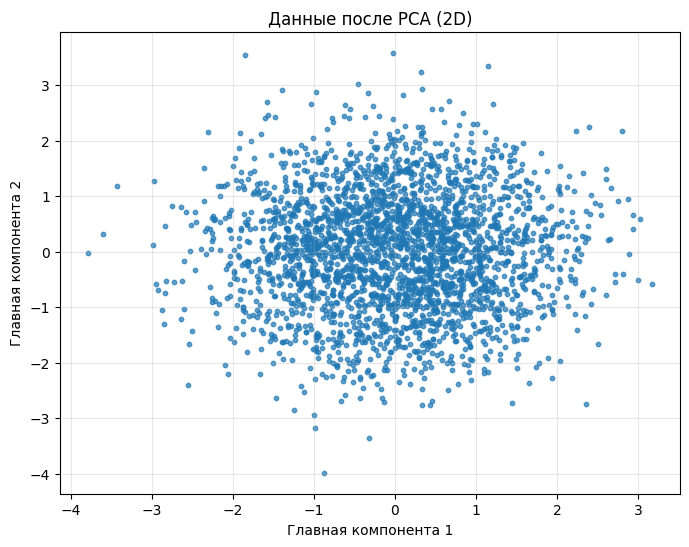

In [62]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.7, s=10)
plt.title('Данные после PCA (2D)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.grid(True, alpha=0.3)
plt.show()

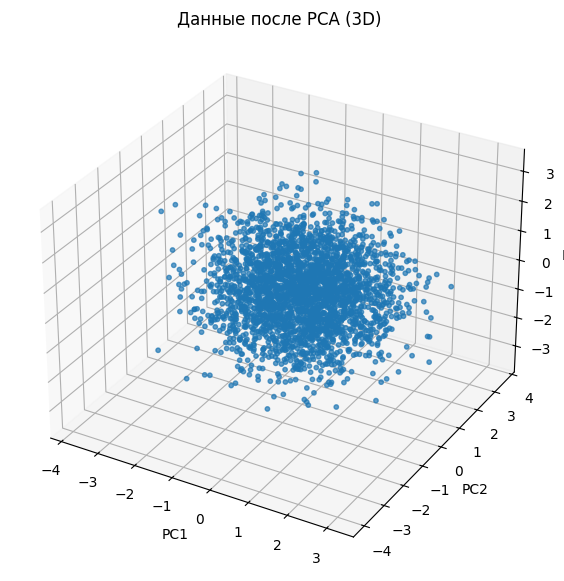

In [63]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], alpha=0.7, s=10)
ax.set_title('Данные после PCA (3D)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

In [64]:
X_pca_2d_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
X_pca_3d_df = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])

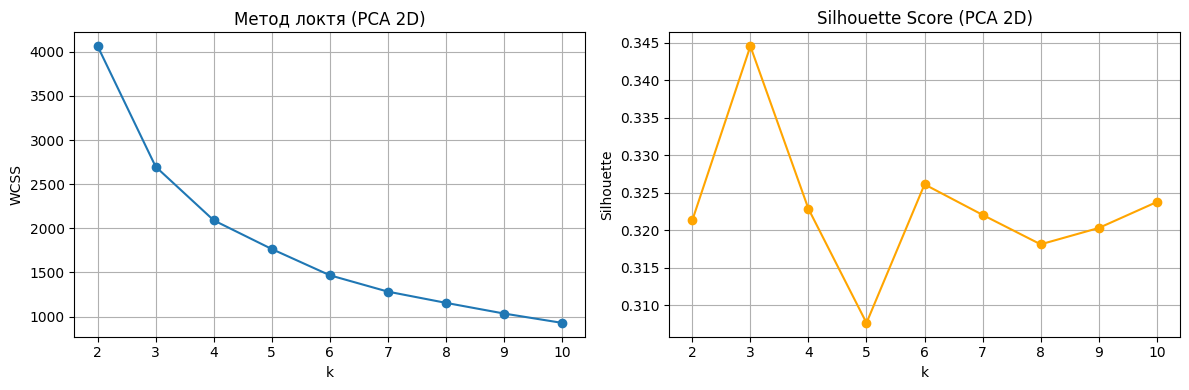

Лучшее k по силуэту на PCA(2D): 3


In [68]:
k_range = range(2, 11)
wcss = []
sil_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_2d_df)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca_2d_df, labels))
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.title('Метод локтя (PCA 2D)')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='o', color='orange')
plt.title('Silhouette Score (PCA 2D)')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.grid()
plt.tight_layout()
plt.show()
best_k_pca = k_range[np.argmax(sil_scores)]
print(f"Лучшее k по силуэту на PCA(2D): {best_k_pca}")

In [70]:
kmeans_pca = KMeans(n_clusters=best_k_pca, random_state=42, n_init=10)
start_time = time.time()
labels_kmeans_pca = kmeans_pca.fit_predict(X_pca_2d_df)
time_kmeans_pca = time.time() - start_time
sil_kmeans_pca = silhouette_score(X_pca_2d_df, labels_kmeans_pca)
db_kmeans_pca = davies_bouldin_score(X_pca_2d_df, labels_kmeans_pca)
ch_kmeans_pca = calinski_harabasz_score(X_pca_2d_df, labels_kmeans_pca)
print(f"K-means на PCA(2D) (k={best_k_pca}):")
print(f"Silhouette: {sil_kmeans_pca:.3f}")
print(f"Davies-Bouldin: {db_kmeans_pca:.3f}")
print(f"Calinski-Harabasz: {ch_kmeans_pca:.1f}")
print(f"Время: {time_kmeans_pca:.3f} сек")

K-means на PCA(2D) (k=3):
Silhouette: 0.345
Davies-Bouldin: 0.920
Calinski-Harabasz: 1725.7
Время: 0.029 сек


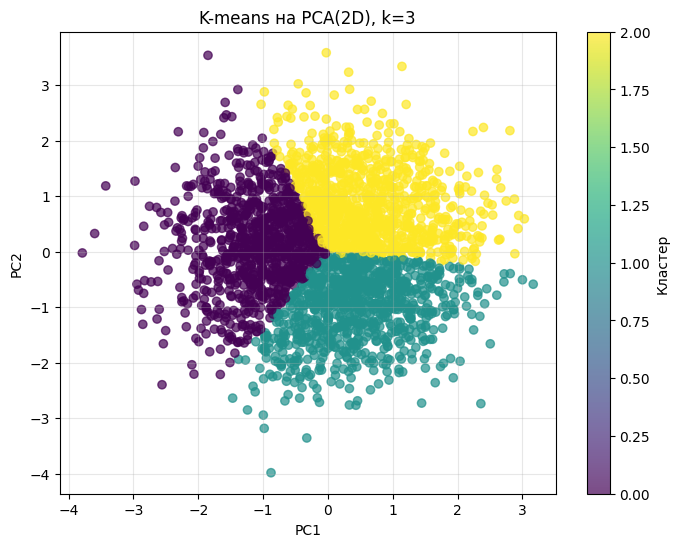

In [71]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_kmeans_pca, cmap='viridis', alpha=0.7)
plt.title(f'K-means на PCA(2D), k={best_k_pca}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Кластер')
plt.grid(True, alpha=0.3)
plt.show()